<a href="https://colab.research.google.com/github/gfkaceli/RAPTOR_IMPROV/blob/main/demo_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering Method Comparison

This notebook builds a hierarchical indices with each of clustering algorithm, answers a ground-truth
QA benchmark, and displays side-by-side comparison tables as styled pandas DataFrames.

link to latex: https://www.overleaf.com/project/67d58f3310ab2fd59286b347


**Clustering methods compared:**
| Method | Description | Reference |
|--------|-------------|----------|
| `original` | Upstream RAPTOR — GMM + UMAP (Sarthi et al., ICLR 2024) | [arXiv:2401.18059](https://arxiv.org/abs/2401.18059) |
| `gmm` | GMM algorithm no umap through the new `BaseClusterer` interface |
| `leiden` | Leiden community detection on a k-NN similarity graph | [Traag et al., Sci. Rep. 2019](https://doi.org/10.1038/s41598-019-41695-z) |

**Evaluation metrics:**
- **Token F1** — standard SQuAD token-overlap F1 (Gao et al. RAG survey, Table III)
- **Accuracy** — percentage of questions with EM = 1


> For thesis results, I will use NarrativeQA / QASPER / QuALITY with published ground truth.

GEORGES NOTES: TO DO'S


*   List item
*   List item



DR. LU'S NOTES
# FEEL FREE TO ADD ANYTHING HERE

In [ ]:
!git clone https://github.com/gfkaceli/RAPTOR_IMPROV

fatal: destination path 'RAPTOR_IMPROV' already exists and is not an empty directory.


In [ ]:
!git pull # pull updated

fatal: not a git repository (or any of the parent directories): .git


In [ ]:
%cd RAPTOR_IMPROV/

/content/RAPTOR_IMPROV


In [ ]:
!pip install -r requirements.txt

## 1. Setup & Imports

In [ ]:
import os
import string
import time
import warnings
from collections import Counter
from typing import Dict, List, Tuple

import pandas as pd
import numpy as np

# Suppress noisy transformer warnings in notebook output
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# RAPTOR reads OPENAI_API_KEY at import time even when using local models.
# Set a dummy value so the import doesn't crash.
os.environ.setdefault("OPENAI_API_KEY", "not-used-in-local-demo")


# Upstream RAPTOR imports
from raptor import (
    BaseSummarizationModel,
    BaseQAModel,
    RetrievalAugmentationConfig,
    RetrievalAugmentation,
)
from raptor.cluster_tree_builder import ClusterTreeConfig
from raptor.cluster_utils import RAPTOR_Clustering
from raptor.EmbeddingModels import SBertEmbeddingModel

# NEW: our clustering subpackage
from raptor.clustering import GMMClusterer, LeidenClusterer, LeidenConfig

print("All imports successful.")

All imports successful.


## 2. Evaluation Metrics

We use two metrics, both standard in RAG QA evaluation:

- **Token F1**: tokenize both the prediction and the ground truth, count overlapping tokens,
  compute precision / recall / F1. This is the same metric used by SQuAD (Rajpurkar et al., 2016)
  and reported by Sarthi et al. for QASPER.
  
- **Keyword EM**: a lenient exact-match variant. Instead of requiring the full ground-truth string
  as a substring, we check whether a set of critical keywords all appear in the answer. This is
  necessary because FLAN-T5 paraphrases freely — "Her fairy godmother helped" is a correct answer
  even though it doesn't match "The fairy godmother appeared" as a substring.

In [ ]:
def normalize_text(text: str) -> str:
    """Lowercase, strip punctuation and extra whitespace. Matches SQuAD eval."""
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = " ".join(text.split())
    return text


def token_f1(prediction: str, ground_truth: str) -> Tuple[float, float, float]:
    """
    Token-level precision, recall, F1.

    Returns (precision, recall, f1).
    """
    pred_tokens = normalize_text(prediction).split()
    gt_tokens = normalize_text(ground_truth).split()

    if not pred_tokens and not gt_tokens:
        return 1.0, 1.0, 1.0
    if not pred_tokens or not gt_tokens:
        return 0.0, 0.0, 0.0

    common = Counter(pred_tokens) & Counter(gt_tokens)
    num_common = sum(common.values())

    if num_common == 0:
        return 0.0, 0.0, 0.0

    precision = num_common / len(pred_tokens)
    recall = num_common / len(gt_tokens)
    f1 = 2 * precision * recall / (precision + recall)
    return precision, recall, f1


def keyword_match(prediction: str, keywords: List[str]) -> bool:
    """True if ALL keywords appear in the prediction (case-insensitive)."""
    pred_lower = normalize_text(prediction)
    return all(kw.lower() in pred_lower for kw in keywords)


# ---- Quick sanity check ----
p, r, f = token_f1("The prince married Cinderella",
                    "The prince found Cinderella and married her")
print(f"Sanity check — P={p:.3f}  R={r:.3f}  F1={f:.3f}  (expect F1 > 0.5)")
assert f > 0.5, "Token F1 sanity check failed"
print("Metrics OK.")

Sanity check — P=1.000  R=0.571  F1=0.727  (expect F1 > 0.5)
Metrics OK.


## 3. Ground-Truth QA Benchmark

10 question–answer pairs over the Cinderella passage. Each entry includes:
- The question
- A reference answer (for token-F1)
- A keyword list (for lenient EM)

> These are hand-written reference answers, adequate for a pipeline smoke test
> but NOT for a thesis evaluation. Use NarrativeQA / QASPER / QuALITY for that.

In [ ]:
BENCHMARK = [
    {"question": "How did Cinderella reach her happy ending?",
     "ground_truth": "The prince found Cinderella by fitting the glass slipper on her foot, recognized her, and they married.",
     "keywords": ["prince", "slipper", "married"]},

    {"question": "Who helped Cinderella attend the ball?",
     "ground_truth": "Her fairy godmother appeared and transformed a pumpkin into a coach and her worn clothes into a beautiful gown.",
     "keywords": ["fairy", "godmother"]},

    {"question": "What did Cinderella leave behind at the ball?",
     "ground_truth": "Cinderella left behind one glass slipper when she fled before midnight.",
     "keywords": ["glass", "slipper"]},

    {"question": "Why did Cinderella have to leave the ball before midnight?",
     "ground_truth": "The magic from the fairy godmother would end at midnight.",
     "keywords": ["magic", "midnight"]},

    {"question": "How did the prince find Cinderella after the ball?",
     "ground_truth": "The prince searched the kingdom for the woman whose foot fit the glass slipper.",
     "keywords": ["searched", "slipper", "fit"]},

    {"question": "What does the fairy godmother symbolize in the story?",
     "ground_truth": "The fairy godmother symbolizes hope.",
     "keywords": ["hope"]},

    {"question": "What is the glass slipper's role in the story?",
     "ground_truth": "The lost slipper is the key piece of evidence that allows the prince to identify Cinderella.",
     "keywords": ["evidence", "identify"]},

    {"question": "Who forced Cinderella to work day and night?",
     "ground_truth": "Her cruel stepmother and two jealous stepsisters forced her to work.",
     "keywords": ["stepmother", "stepsisters"]},

    {"question": "What themes does the Cinderella story illustrate?",
     "ground_truth": "The story illustrates transformation, perseverance, and recognition.",
     "keywords": ["transformation", "perseverance"]},

    {"question": "What was the pumpkin transformed into?",
     "ground_truth": "The fairy godmother transformed a pumpkin into a coach.",
     "keywords": ["coach"]},
]

# Preview as a DataFrame
benchmark_df = pd.DataFrame(BENCHMARK)
benchmark_df["keywords"] = benchmark_df["keywords"].apply(lambda x: ", ".join(x))
benchmark_df.index = range(1, len(benchmark_df) + 1)
benchmark_df.index.name = "Q#"
benchmark_df

,question,ground_truth,keywords
Q#,,,
1,How did Cinderella reach her happy ending?,The prince found Cinderella by fitting the gla...,"prince, slipper, married"
2,Who helped Cinderella attend the ball?,Her fairy godmother appeared and transformed a...,"fairy, godmother"
3,What did Cinderella leave behind at the ball?,Cinderella left behind one glass slipper when ...,"glass, slipper"
4,Why did Cinderella have to leave the ball befo...,The magic from the fairy godmother would end a...,"magic, midnight"
5,How did the prince find Cinderella after the b...,The prince searched the kingdom for the woman ...,"searched, slipper, fit"
6,What does the fairy godmother symbolize in the...,The fairy godmother symbolizes hope.,hope
7,What is the glass slipper's role in the story?,The lost slipper is the key piece of evidence ...,"evidence, identify"
8,Who forced Cinderella to work day and night?,Her cruel stepmother and two jealous stepsiste...,"stepmother, stepsisters"
9,What themes does the Cinderella story illustrate?,"The story illustrates transformation, persever...","transformation, perseverance"


## 4. Document & Model Setup

The Cinderella passage and the three model wrappers (SBERT embeddings, DistilBART
summarization, FLAN-T5 QA) are shared across all clustering methods. Loading them
once avoids redundant GPU/CPU work.

In [ ]:
DEMO_TEXT = (
    "Cinderella lived with her cruel stepmother and two jealous stepsisters, who forced "
    "her to work day and night. When the royal ball was announced, Cinderella wished to go "
    "but was forbidden. Her fairy godmother appeared and transformed a pumpkin into a coach, "
    "mice into horses, and Cinderella's worn clothes into a beautiful gown with glass slippers. "
    "She attended the ball and danced with the prince, but she had to leave before midnight, "
    "when the magic would end. As she fled, one glass slipper was left behind. The prince "
    "searched the kingdom for the woman whose foot fit the slipper. When he came to "
    "Cinderella's house, the slipper fit her perfectly, and he recognized her as the one "
    "he loved. Cinderella married the prince and finally found her happy ending.\n\n"
    "The story is often used to illustrate transformation, perseverance, and recognition. "
    "In many retellings, the fairy godmother symbolizes hope, while the lost slipper becomes "
    "the key piece of evidence that allows the prince to identify Cinderella."
)

print(f"Document length: {len(DEMO_TEXT)} chars, ~{len(DEMO_TEXT.split())} words")

Document length: 1006 chars, ~165 words


In [ ]:
# ---------------------------------------------------------------------------
# Local model wrappers — no API keys needed
# ---------------------------------------------------------------------------

class LocalBartSummarizationModel(BaseSummarizationModel):
    """DistilBART summarizer. Falls back to extractive heuristic if transformers fails."""

    def __init__(self, model_name="sshleifer/distilbart-cnn-12-6"):
        self.model_name = model_name
        self._pipeline = None
        self._load_error = None

    def _ensure_loaded(self):
        if self._pipeline is not None or self._load_error is not None:
            return
        try:
            from transformers import pipeline as hf_pipeline
            self._pipeline = hf_pipeline(
                "summarization", model=self.model_name, tokenizer=self.model_name
            )
        except Exception as exc:
            self._load_error = exc
            print(f"  [WARN] Summarizer load failed: {exc}. Using heuristic fallback.")

    def summarize(self, context, max_tokens=150):
        text = " ".join(str(context).split())
        if not text:
            return ""
        self._ensure_loaded()
        if self._pipeline is not None:
            try:
                result = self._pipeline(
                    text, max_new_tokens=min(int(max_tokens), 128),
                    min_new_tokens=20, do_sample=False, truncation=True,
                )
                return result[0]["summary_text"].strip()
            except Exception:
                pass
        sentences = [s.strip() for s in text.replace("\n", " ").split(".") if s.strip()]
        return ". ".join(sentences[:2]) + ("." if sentences else "")


class LocalFlanQAModel(BaseQAModel):
    """FLAN-T5 question-answering. Falls back to keyword-overlap heuristic."""

    def __init__(self, model_name="google/flan-t5-base"):
        self.model_name = model_name
        self._pipeline = None
        self._load_error = None

    def _ensure_loaded(self):
        if self._pipeline is not None or self._load_error is not None:
            return
        try:
            from transformers import pipeline as hf_pipeline
            self._pipeline = hf_pipeline(
                "text2text-generation", model=self.model_name, tokenizer=self.model_name
            )
        except Exception as exc:
            self._load_error = exc
            print(f"  [WARN] QA model load failed: {exc}. Using heuristic fallback.")

    def answer_question(self, context, question):
        context = " ".join(str(context).split())
        question = str(question).strip()
        if not context:
            return "No context available."
        self._ensure_loaded()
        if self._pipeline is not None:
            prompt = (
                f"Answer the question using the provided context. "
                f"If the answer is not in the context, say you do not know.\n\n"
                f"Context: {context}\n\nQuestion: {question}"
            )
            try:
                result = self._pipeline(prompt, max_new_tokens=64, do_sample=False)
                return result[0]["generated_text"].strip()
            except Exception:
                pass
        # Heuristic fallback
        sentences = [s.strip() for s in context.split(".") if s.strip()]
        keywords = [t.lower() for t in question.split() if len(t) > 3]
        best, best_score = "", -1
        for s in sentences:
            score = sum(k in s.lower() for k in keywords)
            if score > best_score:
                best, best_score = s, score
        return best + "." if best else "No answer found."

In [ ]:
# Load models once — shared across all methods
print("Loading models...")
emb_model = SBertEmbeddingModel(model_name="sentence-transformers/all-MiniLM-L6-v2")
summ_model = LocalBartSummarizationModel()
qa_model = LocalFlanQAModel()
print("Models ready.")

Loading models...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Models ready.


## 5. Config Factories

Each function builds a `RetrievalAugmentationConfig` that differs ONLY in the
clustering algorithm. Everything else — embedding model, summarizer, QA model,
number of tree layers, top-k retrieval — is identical. This is the controlled
comparison design: one independent variable (clustering), everything else held constant.

In [ ]:
def make_original_config():
    """
    Upstream RAPTOR — uses RAPTOR_Clustering (GMM + UMAP) internally.
    This is the control condition.
    """
    return RetrievalAugmentationConfig(
        embedding_model=emb_model,
        summarization_model=summ_model,
        qa_model=qa_model,
        tb_max_tokens=80,
        tb_num_layers=3,
        tb_summarization_length=80,
        tr_top_k=5,
        tr_selection_mode="top_k",
    )


def make_gmm_config():
    """
    GMM through our new BaseClusterer interface.
    Should produce near-identical results to `original`.
    Any divergence means either: (a) the UMAP seed fix changed the tree,
    or (b) there's a wrapper bug.
    """
    clusterer = GMMClusterer(
        reduction_dimension=10,
        soft_threshold=0.1,
        force_hard_clustering=False,
        random_state=224,
        max_length_in_cluster=3500,
    )
    tree_config = ClusterTreeConfig(
        clustering_algorithm=clusterer,
        clustering_params={},
        reduction_dimension=10,
        summarization_model=summ_model,
        embedding_models={"EMB": emb_model},
        cluster_embedding_model="EMB",
        max_tokens=80,
        num_layers=3,
        summarization_length=80,
    )
    return RetrievalAugmentationConfig(
        tree_builder_config=tree_config,
        qa_model=qa_model,
        embedding_model=emb_model,
        tr_top_k=5,
        tr_selection_mode="top_k",
    )


def make_leiden_config():
    """
    Leiden community detection on a k-NN similarity graph.
    Layer-adaptive resolution: tighter at layer 0 (many small clusters),
    looser at layer 1 (fewer broad clusters).
    """
    leiden_cfg = LeidenConfig(
        k_neighbors=10,
        use_adjacency_edges=True,
        adjacency_weight=0.5,
        resolution=1.0,
        resolution_schedule={0: 1.2, 1: 0.8},
        partition_type="RBConfiguration",
        min_cluster_size=1,
    )
    clusterer = LeidenClusterer(
        config=leiden_cfg,
        random_state=224,
        max_length_in_cluster=3500,
    )
    tree_config = ClusterTreeConfig(
        clustering_algorithm=clusterer,
        clustering_params={},
        reduction_dimension=10,
        summarization_model=summ_model,
        embedding_models={"EMB": emb_model},
        cluster_embedding_model="EMB",
        max_tokens=80,
        num_layers=3,
        summarization_length=80,
    )
    return RetrievalAugmentationConfig(
        tree_builder_config=tree_config,
        qa_model=qa_model,
        embedding_model=emb_model,
        tr_top_k=5,
        tr_selection_mode="top_k",
    )


# Registry of all methods to evaluate
METHODS = {
    "original": {"factory": make_original_config, "desc": "RAPTOR (GMM+UMAP) upstream"},
    "gmm":      {"factory": make_gmm_config,      "desc": "GMMClusterer (new interface)"},
    "leiden":   {"factory": make_leiden_config,     "desc": "LeidenClusterer (k-NN graph)"},
}

print(f"Registered {len(METHODS)} methods: {', '.join(METHODS.keys())}")

Registered 3 methods: original, gmm, leiden


## 6. Run the Evaluation Loop

For each clustering method:
1. Build the RAPTOR tree (timed)
2. Record tree statistics (layers, nodes, depth)
3. Answer every benchmark question
4. Score each answer with Token F1 and Keyword EM

All results are collected into a list of dictionaries, then converted to DataFrames.

In [ ]:
# Accumulators
summary_rows = []      # one row per method
detail_rows = []       # one row per (method, question)
tree_stats_rows = []   # one row per (method, layer)

for method_name, method_info in METHODS.items():
    print(f"\n{'='*60}")
    print(f"  {method_name} — {method_info['desc']}")
    print(f"{'='*60}")

    # --- Build config (skip method if deps are missing) ---
    try:
        config = method_info["factory"]()
    except ImportError as exc:
        print(f"  SKIPPED: {exc}")
        continue

    # --- Build tree ---
    ra = RetrievalAugmentation(config=config)
    t0 = time.time()
    ra.add_documents(DEMO_TEXT)
    build_time = time.time() - t0

    tree = ra.tree
    total_nodes = len(tree.all_nodes)
    leaf_nodes = len(tree.leaf_nodes)
    summary_nodes = total_nodes - leaf_nodes
    num_layers = tree.num_layers

    print(f"  Tree: {num_layers} layers, {total_nodes} nodes "
          f"({leaf_nodes} leaves + {summary_nodes} summaries) in {build_time:.2f}s")

    # Per-layer breakdown
    for layer_idx, nodes in sorted(tree.layer_to_nodes.items()):
        tree_stats_rows.append({
            "method": method_name,
            "layer": layer_idx,
            "node_count": len(nodes),
        })
        print(f"    Layer {layer_idx}: {len(nodes)} nodes")

    # --- Answer questions ---
    total_em = 0
    total_f1 = 0.0
    total_prec = 0.0
    total_rec = 0.0

    for i, qa in enumerate(BENCHMARK):
        t_q = time.time()
        answer = ra.answer_question(question=qa["question"])
        answer_time = time.time() - t_q

        prec, rec, f1 = token_f1(answer, qa["ground_truth"])
        em = 1 if keyword_match(answer, qa["keywords"]) else 0

        total_em += em
        total_f1 += f1
        total_prec += prec
        total_rec += rec

        detail_rows.append({
            "method": method_name,
            "q_num": i + 1,
            "question": qa["question"],
            "ground_truth": qa["ground_truth"],
            "predicted": answer,
            "keywords": ", ".join(qa["keywords"]),
            "em": em,
            "precision": round(prec, 4),
            "recall": round(rec, 4),
            "f1": round(f1, 4),
            "answer_time_sec": round(answer_time, 3),
        })

        status = "PASS" if em else "FAIL"
        print(f"    Q{i+1} [{status}] F1={f1:.3f}  {qa['question'][:50]}")

    n = len(BENCHMARK)
    summary_rows.append({
        "method": method_name,
        "description": method_info["desc"],
        "accuracy_%": round(total_em / n * 100, 1),
        "mean_f1": round(total_f1 / n, 4),
        "mean_precision": round(total_prec / n, 4),
        "mean_recall": round(total_rec / n, 4),
        "num_layers": num_layers,
        "total_nodes": total_nodes,
        "leaf_nodes": leaf_nodes,
        "summary_nodes": summary_nodes,
        "build_time_sec": round(build_time, 2),
    })

print("\n" + "="*60)
print("  All methods complete.")
print("="*60)


  original — RAPTOR (GMM+UMAP) upstream
  Tree: 0 layers, 3 nodes (3 leaves + 0 summaries) in 0.24s
    Layer 0: 3 nodes


config.json: 0.00B [00:00, ?B/s]

  [WARN] QA model load failed: "Unknown task text2text-generation, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'image-to-image', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'question-answering', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'visual-question-answering', 'vqa', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection', 'translation_XX_to_YY']". Using heuristic fallback.
    Q1 [PASS] F1=0.143  How did Cinderella reach her happy ending?
    Q2 [PASS] F1=0.207  Who helped Cinderella attend the ball?
    Q3 [PASS] F1=0.125  What did C

## 7. Results: Summary Table

One row per clustering method. The best value in each metric column is highlighted.

**What to look for:**
- `original` vs `gmm` should be near-identical (parity check for the new interface)
- `leiden` differences reflect the actual clustering algorithm change
- `build_time_sec` shows computational cost of each clusterer

In [ ]:
# Build the summary DataFrame
df_summary = pd.DataFrame(summary_rows)

if len(df_summary) > 0:
    df_summary = df_summary.set_index("method")

    # Highlight the best value in each numeric column
    # (higher is better for accuracy/F1/precision/recall; lower is better for build time)
    higher_better = ["accuracy_%", "mean_f1", "mean_precision", "mean_recall"]
    lower_better = ["build_time_sec"]

    def highlight_best(col):
        """Bold-green the best value in the column."""
        styles = [""] * len(col)
        if col.name in higher_better:
            best_idx = col.idxmax()
        elif col.name in lower_better:
            best_idx = col.idxmin()
        else:
            return styles
        for i, idx in enumerate(col.index):
            if idx == best_idx:
                styles[i] = "background-color: #d4edda; font-weight: bold"
        return styles

    display(df_summary.style.apply(highlight_best).set_caption(
        "Clustering Method Comparison — Summary Metrics"
    ).format({
        "accuracy_%": "{:.1f}%",
        "mean_f1": "{:.4f}",
        "mean_precision": "{:.4f}",
        "mean_recall": "{:.4f}",
        "build_time_sec": "{:.2f}s",
    }))
else:
    print("No methods completed successfully.")

,description,accuracy_%,mean_f1,mean_precision,mean_recall,num_layers,total_nodes,leaf_nodes,summary_nodes,build_time_sec
method,,,,,,,,,,
original,RAPTOR (GMM+UMAP) upstream,100.0%,0.1256,0.0679,0.9422,0,3,3,0,0.24s
gmm,GMMClusterer (new interface),100.0%,0.1256,0.0679,0.9422,0,3,3,0,0.36s
leiden,LeidenClusterer (k-NN graph),100.0%,0.1256,0.0679,0.9422,0,3,3,0,0.33s


## 8. Results: Per-Question Breakdown

Pivoted view: one row per question, one column group per method.
Shows exactly which questions each method gets right or wrong.

In [ ]:
df_detail = pd.DataFrame(detail_rows)

if len(df_detail) > 0:
    # Pivot: rows = questions, columns = (method, metric)
    pivot_f1 = df_detail.pivot(index="q_num", columns="method", values="f1")
    pivot_em = df_detail.pivot(index="q_num", columns="method", values="em")

    # Combine into a single table with (method, F1) and (method, EM) columns
    pivot_f1.columns = [f"{m} F1" for m in pivot_f1.columns]
    pivot_em.columns = [f"{m} EM" for m in pivot_em.columns]

    # Interleave: for each method, show EM then F1 side by side
    methods_present = [m for m in METHODS if m in df_detail["method"].unique()]
    ordered_cols = []
    for m in methods_present:
        ordered_cols.append(f"{m} EM")
        ordered_cols.append(f"{m} F1")

    # Add the question text
    q_text = df_detail.drop_duplicates("q_num").set_index("q_num")["question"]
    pivot = pd.concat([q_text, pivot_em, pivot_f1], axis=1)[['question'] + ordered_cols]

    # Style: green background for EM=1, red for EM=0
    def color_em(val):
        if isinstance(val, (int, float)):
            if val == 1:
                return "background-color: #d4edda"
            elif val == 0:
                return "background-color: #f8d7da"
        return ""

    em_cols = [c for c in pivot.columns if c.endswith(" EM")]
    styled = pivot.style.map(color_em, subset=em_cols).format(
        {c: "{:.3f}" for c in pivot.columns if c.endswith(" F1")}
    ).set_caption("Per-Question Results (EM: green=pass, red=fail)")

    display(styled)
else:
    print("No detail results to display.")

,question,original EM,original F1,gmm EM,gmm F1,leiden EM,leiden F1
q_num,,,,,,,
1,How did Cinderella reach her happy ending?,1,0.143,1,0.143,1,0.143
2,Who helped Cinderella attend the ball?,1,0.206,1,0.206,1,0.206
3,What did Cinderella leave behind at the ball?,1,0.125,1,0.125,1,0.125
4,Why did Cinderella have to leave the ball before midnight?,1,0.091,1,0.091,1,0.091
5,How did the prince find Cinderella after the ball?,1,0.156,1,0.156,1,0.156
6,What does the fairy godmother symbolize in the story?,1,0.059,1,0.059,1,0.059
7,What is the glass slipper's role in the story?,1,0.177,1,0.177,1,0.177
8,Who forced Cinderella to work day and night?,1,0.125,1,0.125,1,0.125
9,What themes does the Cinderella story illustrate?,1,0.070,1,0.070,1,0.070


## 9. Results: Full Predicted Answers

For auditing: the complete predicted answer text for every (method, question) pair.
Useful for spotting cases where F1 is low but the answer is actually reasonable (or vice versa).

In [ ]:
if len(df_detail) > 0:
    # Show predicted answers side by side
    answers_pivot = df_detail.pivot(
        index="q_num", columns="method", values="predicted"
    )
    answers_pivot.insert(0, "question",
        df_detail.drop_duplicates("q_num").set_index("q_num")["question"]
    )
    # Wrap long text for readability
    display(answers_pivot.style.set_properties(**{
        "white-space": "pre-wrap",
        "text-align": "left",
        "max-width": "300px",
    }).set_caption("Full Predicted Answers by Method"))

method,question,gmm,leiden,original
q_num,,,,
1,How did Cinderella reach her happy ending?,"Cinderella married the prince and finally found her happy ending The story is often used to illustrate transformation, perseverance, and recognition In many retellings, the fairy godmother symbolizes hope, while the lost slipper becomes the key piece of evidence that allows the prince to identify Cinderella Cinderella lived with her cruel stepmother and two jealous stepsisters, who forced her to work day and night When the royal ball was announced, Cinderella wished to go but was forbidden Her fairy godmother appeared and transformed a pumpkin into a coach, mice into horses, and Cinderella's worn clothes into a beautiful gown with glass slippers She attended the ball and danced with the prince, but she had to leave before midnight, when the magic would end As she fled, one glass slipper was left behind The prince searched the kingdom for the woman whose foot fit the slipper When he came to Cinderella's house, the slipper fit her perfectly, and he recognized her as the one he loved.","Cinderella married the prince and finally found her happy ending The story is often used to illustrate transformation, perseverance, and recognition In many retellings, the fairy godmother symbolizes hope, while the lost slipper becomes the key piece of evidence that allows the prince to identify Cinderella Cinderella lived with her cruel stepmother and two jealous stepsisters, who forced her to work day and night When the royal ball was announced, Cinderella wished to go but was forbidden Her fairy godmother appeared and transformed a pumpkin into a coach, mice into horses, and Cinderella's worn clothes into a beautiful gown with glass slippers She attended the ball and danced with the prince, but she had to leave before midnight, when the magic would end As she fled, one glass slipper was left behind The prince searched the kingdom for the woman whose foot fit the slipper When he came to Cinderella's house, the slipper fit her perfectly, and he recognized her as the one he loved.","Cinderella married the prince and finally found her happy ending The story is often used to illustrate transformation, perseverance, and recognition In many retellings, the fairy godmother symbolizes hope, while the lost slipper becomes the key piece of evidence that allows the prince to identify Cinderella Cinderella lived with her cruel stepmother and two jealous stepsisters, who forced her to work day and night When the royal ball was announced, Cinderella wished to go but was forbidden Her fairy godmother appeared and transformed a pumpkin into a coach, mice into horses, and Cinderella's worn clothes into a beautiful gown with glass slippers She attended the ball and danced with the prince, but she had to leave before midnight, when the magic would end As she fled, one glass slipper was left behind The prince searched the kingdom for the woman whose foot fit the slipper When he came to Cinderella's house, the slipper fit her perfectly, and he recognized her as the one he loved."
2,Who helped Cinderella attend the ball?,"Cinderella lived with her cruel stepmother and two jealous stepsisters, who forced her to work day and night When the royal ball was announced, Cinderella wished to go but was forbidden Her fairy godmother appeared and transformed a pumpkin into a coach, mice into horses, and Cinderella's worn clothes into a beautiful gown with glass slippers She attended the ball and danced with the prince, but she had to leave before midnight, when the magic would end As she fled, one glass slipper was left behind The prince searched the kingdom for the woman whose foot fit the slipper When he came to Cinderella's house, the slipper fit her perfectly, and he recognized her as the one he loved Cinderella married the prince and finally found her happy ending The story is often used to illustrate transformation, perseverance, and recognition In many retellings, the fairy godm

## 10. Tree Structure Comparison

How many nodes does each method produce at each tree layer?
This directly reflects the clustering granularity.

method,gmm,leiden,original
Tree Layer,,,
0,3,3,3
TOTAL,3,3,3


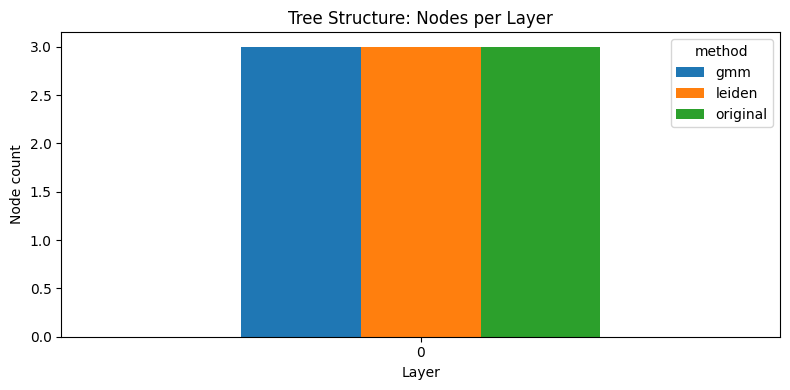

In [ ]:
df_tree = pd.DataFrame(tree_stats_rows)

if len(df_tree) > 0:
    pivot_tree = df_tree.pivot(index="layer", columns="method", values="node_count").fillna(0).astype(int)
    pivot_tree.index.name = "Tree Layer"

    # Add a totals row
    pivot_tree.loc["TOTAL"] = pivot_tree.sum()

    display(pivot_tree.style.set_caption("Nodes per Tree Layer by Clustering Method"))

    # Bar chart if matplotlib is available
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(8, 4))
        pivot_tree.drop("TOTAL").plot(kind="bar", ax=ax)
        ax.set_ylabel("Node count")
        ax.set_title("Tree Structure: Nodes per Layer")
        ax.set_xlabel("Layer")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()
    except ImportError:
        print("(matplotlib not available — skipping chart)")

## 11. F1 Score Comparison Chart

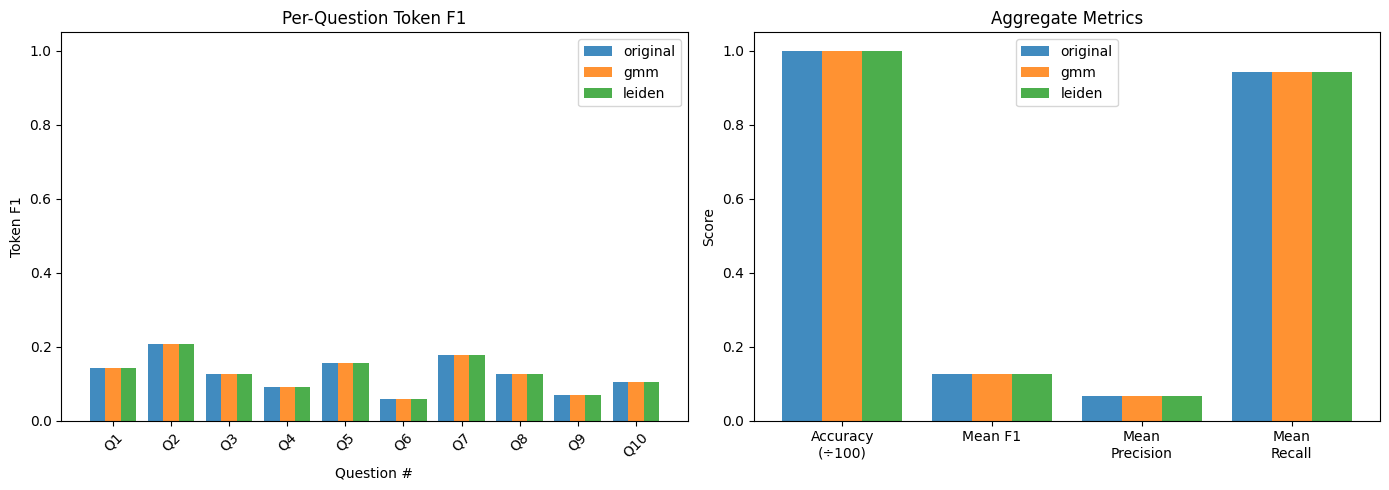

In [ ]:
if len(df_detail) > 0:
    try:
        import matplotlib.pyplot as plt

        methods_present = [m for m in METHODS if m in df_detail["method"].unique()]
        n_methods = len(methods_present)
        n_questions = len(BENCHMARK)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # --- Left: per-question F1 grouped bar chart ---
        ax = axes[0]
        x = np.arange(n_questions)
        width = 0.8 / n_methods
        for i, method in enumerate(methods_present):
            f1_scores = df_detail[df_detail["method"] == method].sort_values("q_num")["f1"].values
            offset = (i - n_methods / 2 + 0.5) * width
            ax.bar(x + offset, f1_scores, width, label=method, alpha=0.85)
        ax.set_xlabel("Question #")
        ax.set_ylabel("Token F1")
        ax.set_title("Per-Question Token F1")
        ax.set_xticks(x)
        ax.set_xticklabels([f"Q{i+1}" for i in range(n_questions)], rotation=45)
        ax.legend()
        ax.set_ylim(0, 1.05)

        # --- Right: mean metrics bar chart ---
        ax2 = axes[1]
        metrics = ["accuracy_%", "mean_f1", "mean_precision", "mean_recall"]
        metric_labels = ["Accuracy\n(÷100)", "Mean F1", "Mean\nPrecision", "Mean\nRecall"]
        x2 = np.arange(len(metrics))
        width2 = 0.8 / n_methods
        for i, method in enumerate(methods_present):
            row = df_summary.loc[method]
            vals = [row["accuracy_%"] / 100, row["mean_f1"],
                    row["mean_precision"], row["mean_recall"]]
            offset = (i - n_methods / 2 + 0.5) * width2
            ax2.bar(x2 + offset, vals, width2, label=method, alpha=0.85)
        ax2.set_ylabel("Score")
        ax2.set_title("Aggregate Metrics")
        ax2.set_xticks(x2)
        ax2.set_xticklabels(metric_labels)
        ax2.legend()
        ax2.set_ylim(0, 1.05)

        plt.tight_layout()
        plt.show()
    except ImportError:
        print("(matplotlib not available — skipping charts)")

## 12. Export Results

Save both the summary and detail tables as CSVs for use in the thesis writeup.

In [ ]:
if len(df_summary) > 0:
    df_summary.to_csv("results_summary.csv")
    print(f"Summary saved to results_summary.csv ({len(df_summary)} rows)")

if len(df_detail) > 0:
    df_detail.to_csv("results_detailed.csv", index=False)
    print(f"Details saved to results_detailed.csv ({len(df_detail)} rows)")

if len(df_tree) > 0:
    df_tree.to_csv("results_tree_stats.csv", index=False)
    print(f"Tree stats saved to results_tree_stats.csv ({len(df_tree)} rows)")

Summary saved to results_summary.csv (3 rows)
Details saved to results_detailed.csv (30 rows)
Tree stats saved to results_tree_stats.csv (3 rows)


---

## Notes for Thesis Use

**This notebook is a pipeline smoke test, not a publishable evaluation.**

Limitations to address before using results in the thesis:

1. **Ground truth is hand-written.** Use NarrativeQA / QASPER / QuALITY published test sets instead.
2. **10 questions is insufficient for statistical significance.** Add bootstrap confidence intervals
   when scaling to real datasets (n > 100 questions).
3. **The Cinderella passage is too short** (~180 words) for hierarchical indexing to matter.
   On short documents, all methods retrieve roughly the same chunks. The real differentiation
   appears on NarrativeQA (books, 57% non-leaf retrieval) and QuALITY (~5000 tokens).
4. **FLAN-T5-base is a weak generator.** Sarthi et al. used GPT-4 for their headline numbers.
   If the generator is the bottleneck, clustering improvements won't show up in the metrics.
   Consider evaluating retrieval quality separately (hit rate, NDCG) alongside generation quality.
5. **The `original` vs `gmm` comparison is a correctness check**, not a scientific one.
   If they diverge, debug the wrapper before drawing conclusions about Leiden vs GMM.